# Multi-scenario multi-objective robust decision-making (multi-scenario MORDM)

This notebook describes how multi-scenario multi-objective robust decision-making (MORDM) was used to find robust policies to deal with the flood risk of the IJssel river. A traditional multi-scenario MORDM uses the results of a single scenario MORDM to create new scenarios for which the multi-scenario MORDM is performed. Due to computational issues and some time constraints it was decided to make an adapted multi-scenario MORDM. The scenarios in this version are based on the open exploration results instead of the outcomes of a single scenario MORDM.

The approach for the multi-scenario MORDM consists of four steps:
1. Problem formulation
2. Searching for candidate solutions
3. Re-evaluate candidate solutions under uncertainty
4. Performing a scenario discovery

These four steps are based on 'assignment 9 - MORDM' of the course EPA141A: https://github.com/quaquel/epa141A_open/tree/master/Week%205-6%20-%20robustness%20and%20direct%20search

*The full reference of other in text references used in this notebook can be found in the reference list of the final report.*

## Step 1: Problem formulation

First, the model is imported as dike_model using problem formulation 2. Meaning that the outcomes of the model are:
* Expected annual damage
* Dike investment costs
* RfR investment costs
* Evacuation costs
* Expected number of deaths

For the optimization, the outcomes have a direction in which they are optimized (minimize or maximize). The default of the model is to minimize for all five outcomes. The Environmental Interest Group feels that the costs of RfR projects are worth it, and they do not mind if they are not as low as possible. However, all stakeholders need to agree on a policy for it to be implemented effectively, and they often want to minimize the costs. That is why RfR investment costs are minimized as well.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pickle


# Import EMA Workbench for exploratory modelling and analysis
from ema_workbench import (Policy, ema_logging, MultiprocessingEvaluator, Scenario)

from problem_formulation import get_model_for_problem_formulation

from ema_workbench.em_framework.optimization import (EpsilonProgress, ArchiveLogger)
from ema_workbench.analysis import parcoords

from collections import OrderedDict

from ema_workbench.util.utilities import (save_results, load_results)
from ema_workbench.analysis import prim

In [3]:
dike_model, planning_steps = get_model_for_problem_formulation(2)

In [4]:
# Check the directions the variables are optimizing to
for outcome in dike_model.outcomes:
    print(f"Outcome: {outcome.name}, Direction: {outcome.kind}")

Outcome: Expected Annual Damage, Direction: -1
Outcome: Dike Investment Costs, Direction: -1
Outcome: RfR Investment Costs, Direction: -1
Outcome: Evacuation Costs, Direction: -1
Outcome: Expected Number of Deaths, Direction: -1


### Defining reference scenarios

To increase the robustness in the search phase, the optimization will be run for three different scenarios. One with the mean values for the uncertainties, one representing a best case, and a worst case. The best and worst case reference scenarios are based on the results from the open exploration. The best case scenario from the perspective of the Environmental Interest Group is a lot of Room for the River projects and few casualties. Therefore, the scenario that resulted in the lowest expected number of deaths for the policy ‘RfR only’ was chosen as the best case scenario. Furthermore, the Environmental Interest Group is opposed to dike heightening. The scenario with ‘Dikes only’ and the highest expected number of deaths was therefore chosen as the worst case scenario.

In [5]:
reference_scenario_mean = Scenario('reference_mean', **{'discount rate 0': 2.5, 'discount rate 1': 2.5, 'discount rate 2': 2.5, 'A.0_ID flood wave shape': 66,
                                              'A.1_Bmax': 190, 'A.1_pfail': 0.5, 'A.1_Brate': 1.5,
                                              'A.2_Bmax': 190, 'A.2_pfail': 0.5, 'A.2_Brate': 1.5,
                                              'A.3_Bmax': 190, 'A.3_pfail': 0.5, 'A.3_Brate': 1.5,
                                              'A.4_Bmax': 190, 'A.4_pfail': 0.5, 'A.4_Brate': 1.5,
                                              'A.5_Bmax': 190, 'A.5_pfail': 0.5, 'A.5_Brate': 1.5})

In [6]:
# import data from open exploration - best case
with open("reference_uncertainties_rfr_only.pkl", "rb") as f:
    min_rfr_uncertainties_df = pickle.load(f)
rfr_reference = min_rfr_uncertainties_df.iloc[0]

In [7]:
# Create the best case reference scenario based on open exploration results
ordered_reference_values_best = OrderedDict([
    ('discount rate 0', rfr_reference['discount rate 0']),
    ('discount rate 1', rfr_reference['discount rate 1']),
    ('discount rate 2', rfr_reference['discount rate 2']),
    ('A.0_ID flood wave shape', rfr_reference['A.0_ID flood wave shape']),
    ('A.1_Bmax', rfr_reference['A.1_Bmax']),
    ('A.1_pfail', rfr_reference['A.1_pfail']),
    ('A.1_Brate', rfr_reference['A.1_Brate']),
    ('A.2_Bmax', rfr_reference['A.2_Bmax']),
    ('A.2_pfail', rfr_reference['A.2_pfail']),
    ('A.2_Brate', rfr_reference['A.2_Brate']),
    ('A.3_Bmax', rfr_reference['A.3_Bmax']),
    ('A.3_pfail', rfr_reference['A.3_pfail']),
    ('A.3_Brate', rfr_reference['A.3_Brate']),
    ('A.4_Bmax', rfr_reference['A.4_Bmax']),
    ('A.4_pfail', rfr_reference['A.4_pfail']),
    ('A.4_Brate', rfr_reference['A.4_Brate']),
    ('A.5_Bmax', rfr_reference['A.5_Bmax']),
    ('A.5_pfail', rfr_reference['A.5_pfail']),
    ('A.5_Brate', rfr_reference['A.5_Brate'])
])

reference_scenario_best = Scenario('reference_best', **ordered_reference_values_best)

In [8]:
# import data from open exploration - worst case
with open("reference_uncertainties_dikes_only.pkl", "rb") as f:
    min_dike_uncertainties_df = pickle.load(f)
worst_reference = min_dike_uncertainties_df.iloc[0]

In [9]:
# Create the worst case reference scenario based on open exploration results
ordered_reference_values_worst = OrderedDict([
    ('discount rate 0', worst_reference['discount rate 0']),
    ('discount rate 1', worst_reference['discount rate 1']),
    ('discount rate 2', worst_reference['discount rate 2']),
    ('A.0_ID flood wave shape', worst_reference['A.0_ID flood wave shape']),
    ('A.1_Bmax', worst_reference['A.1_Bmax']),
    ('A.1_pfail', worst_reference['A.1_pfail']),
    ('A.1_Brate', worst_reference['A.1_Brate']),
    ('A.2_Bmax', worst_reference['A.2_Bmax']),
    ('A.2_pfail', worst_reference['A.2_pfail']),
    ('A.2_Brate', worst_reference['A.2_Brate']),
    ('A.3_Bmax', worst_reference['A.3_Bmax']),
    ('A.3_pfail', worst_reference['A.3_pfail']),
    ('A.3_Brate', worst_reference['A.3_Brate']),
    ('A.4_Bmax', worst_reference['A.4_Bmax']),
    ('A.4_pfail', worst_reference['A.4_pfail']),
    ('A.4_Brate', worst_reference['A.4_Brate']),
    ('A.5_Bmax', worst_reference['A.5_Bmax']),
    ('A.5_pfail', worst_reference['A.5_pfail']),
    ('A.5_Brate', worst_reference['A.5_Brate'])
])

reference_scenario_worst = Scenario('reference_worst', **ordered_reference_values_worst)

In [10]:
# Create a list with the three different scenarios
reference_scenarios = [reference_scenario_mean, reference_scenario_best, reference_scenario_worst]

## Step 2: Searching for candidate solutions

In step 2, a multi-objective evolutionary algorithm (MOEA) is used to search over the decision levers to find candidate solutions for the three reference scenarios defined in step 1. After the optimization, a seed analysis is performed to check if the epsilon progress also converges for different seeds. Finally, the results of the optimization are plotted in a parallel coordinate plot which can give insights into the trade-offs that play a role.

### Optimization
The optimization is run for 200.000 nfe and an epsilon value of 0.25. The epsilon progress is tracked, and this indicates if a high enough number of function evaluation (nfe) was chosen.

In [ ]:
# Optimization for 1 seed for three reference scenarios
ema_logging.log_to_stderr(ema_logging.INFO)

convergence_metrics = [EpsilonProgress()]
nfe = 200000
epsilon = [0.25] * len(dike_model.outcomes)

with MultiprocessingEvaluator(dike_model) as evaluator:
    for i, scenario in enumerate(reference_scenarios):
        results = evaluator.optimize(
            nfe=nfe,
            searchover='levers',
            epsilons=epsilon,
            convergence=convergence_metrics,
            reference=scenario
        )
        # with open(f"results200_{scenario.name}.pkl", "wb") as f:
        #     pickle.dump(results, f)

[MainProcess/INFO] pool started with 8 workers
200179it [1:48:24, 30.78it/s]
[MainProcess/INFO] optimization completed, found 184 solutions
200179it [1:46:53, 31.21it/s]
[MainProcess/INFO] optimization completed, found 132 solutions
200757it [1:49:55, 30.44it/s]
[MainProcess/INFO] optimization completed, found 305 solutions
[MainProcess/INFO] terminating pool


184 solutions were found for reference_mean
132 solutions were found for reference_best
305 solutions were found for reference_worst


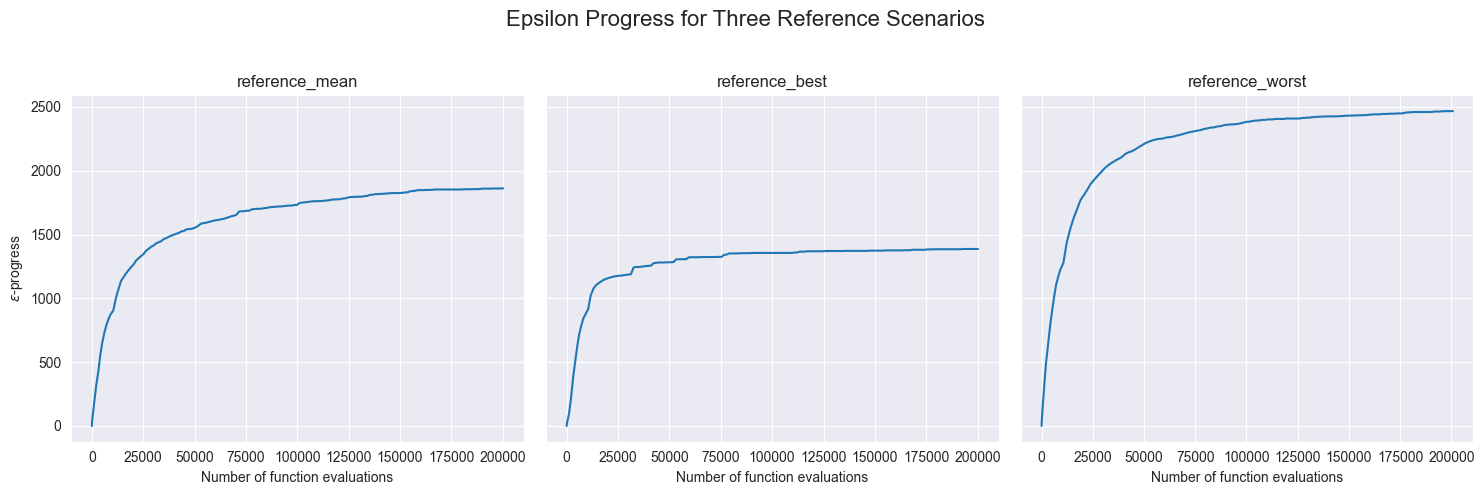

In [14]:
# Create one figure with 3 subplots in a row
fig, axs = plt.subplots(1, 3, figsize=(15, 5), sharey=True)

for i, scenario in enumerate(reference_scenarios):
    with open(f"results200_{scenario.name}.pkl", "rb") as f:
        archive, convergence = pickle.load(f)
    # Print the number of solutions per reference scenario
    print(len(archive), 'solutions were found for', scenario.name)

    # Plot epsilon progress for each reference scenario
    axs[i].plot(convergence.nfe, convergence.epsilon_progress)
    axs[i].set_title(scenario.name)
    axs[i].set_xlabel('Number of function evaluations')
    if i == 0:
        axs[i].set_ylabel(r'$\epsilon$-progress')


fig.suptitle('Epsilon Progress for Three Reference Scenarios', fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.95])

fig.savefig("Epsilon_progress200.png", dpi=300)
plt.show()

The epsilon progress is converging for all three reference scenarios. Ideally, the optimization would be run again for an even larger number of nfe to ensure that the reference_mean and reference_worst are indeed stabilized. Because of a large computational time for running the code above, this has not been done.


### Seed analysis
To check whether the epsilon progress also converges if different seeds are used, a seed analysis is performed. This is important because the MOEA is partly based on processes including randomness. To ensure that the convergence of the epsilon progress is not a coincidence due to randomness, the optimization is run again for 3 seeds. Due to a lack of computational power we only ran the seed analysis for three seeds for the reference scenario with the mean values. Preferably, you would also run it for a few more seeds and for the other two reference scenarios.

In [ ]:
results = []
convergences = []

# Optimization for 3 seeds for reference scenarios mean
with MultiprocessingEvaluator(dike_model) as evaluator:
    # run for 3 seeds
    for i in range(3):

        # the archive logger writes the archive to disk for every x nfe
        # the epsilon progress tracks during runtime
        convergence_metrics = [
            ArchiveLogger(
                "./archives",
                [l.name for l in dike_model.levers],
                [o.name for o in dike_model.outcomes],
                base_filename=f"{i}.tar.gz",
            ),
            EpsilonProgress(),
        ]

        result, convergence = evaluator.optimize(
            nfe=200000,
            searchover='levers',
            epsilons=[0.25] * 5,
            convergence=convergence_metrics,
            reference=reference_scenario_mean
        )

        results.append(result)
        convergences.append(convergence)

# Combine both lists into a dictionary for clarity
combined_data = {
    "results": results,
    "convergences": convergences
}

# Save data of three seeds to a pickle file
# with open("seed_analysis_5.pkl", "wb") as f:
#     pickle.dump(combined_data, f)

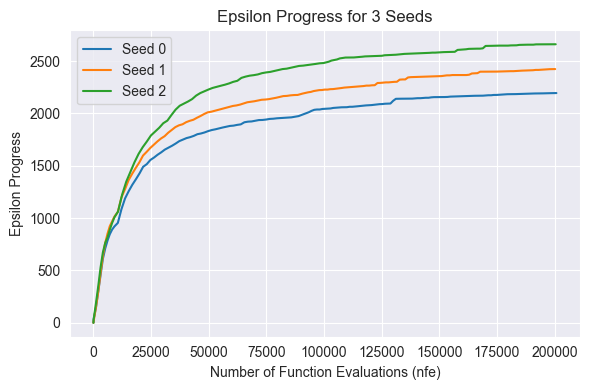

In [13]:
# Import data from seed analysis with 3 seeds
with open("seed_analysis_5.pkl", "rb") as f:
    data = pickle.load(f)

results = data["results"]
convergences = data["convergences"]

# Plot the epsilon progress for the different seeds
plt.figure(figsize=(6, 4))

for i, df in enumerate(convergences):
    plt.plot(df['nfe'], df['epsilon_progress'], label=f'Seed {i}')

plt.xlabel('Number of Function Evaluations (nfe)')
plt.ylabel('Epsilon Progress')
plt.title('Epsilon Progress for 3 Seeds')
plt.legend()
plt.grid(True)
plt.tight_layout()

plt.savefig("Seed_analysis.png", dpi=300)

plt.show()

The seed analysis shows that the epsilon progress follows the same trajectory for the three seeds. However, as mentioned after the plot of the epsilon progress of one seed, it would be preferable to run the optimization for an even larger number of nfe. Ideally, you would want the lines to all stabilize around the same value, because it indicates 'that the seeds are converging to similar sets of solutions' (Directed Search — Exploratory Modeling Workbench, n.d.). In the plot it can be seen that the lines roughly reach the same value, but running with more nfe would give more certainty that this is indeed the case. However, with the time constraint of this course it was decided that these outcomes are acceptable and the analysis was continued with the results of the optimization with 200.000 nfe.

Furthermore, it would have been a good addition to also track the hypervolume, but creating a reference set with epsilon_nondominated gave an error that we, and many fellow students, unfortunately did not manage to solve. The hypervolume would have given more insight in the convergence for the different seeds.


### Optimization results
The optimization outcomes of the three reference scenarios are combined and duplicate candidate solutions are dropped. This combined archive includes all the found candidate solutions and they are plotted in a parallel coordinate plot.

In [17]:
# Empty list to combine archive DataFrames
all_archives = []

for scenario in reference_scenarios:
    with open(f"results200_{scenario.name}.pkl", "rb") as f: 
        archive, convergence = pickle.load(f)

    all_archives.append(archive)

combined_archive = pd.concat(all_archives, ignore_index=True)

# Remove duplicates
combined_archive = combined_archive.drop_duplicates()

# Check the number of candidate solutions
print(len(combined_archive), 'unique candidate solutions were found')

# Save for further analysis
#combined_archive.to_pickle("combined_archive200.pkl")

621 unique candidate solutions were found


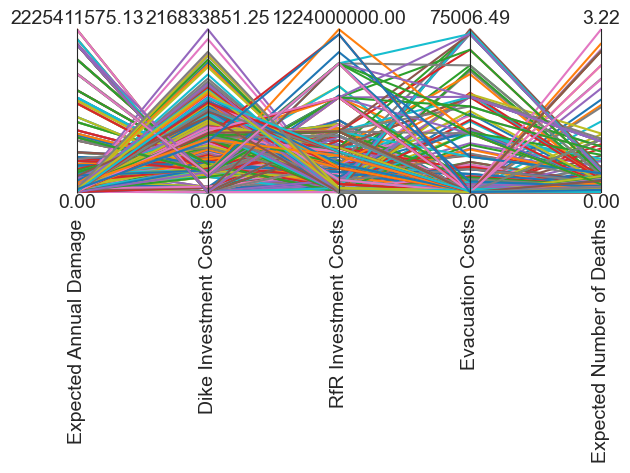

In [109]:
# Use combined archive to create parallel coordinate plot
combined_archive = pd.read_pickle("combined_archive200.pkl")

outcomes = combined_archive.loc[:, [
    'Expected Annual Damage',
    'Dike Investment Costs',
    'RfR Investment Costs',
    'Evacuation Costs',
    'Expected Number of Deaths'
]]

limits = parcoords.get_limits(outcomes)
axes = parcoords.ParallelAxes(limits)
axes.plot(outcomes)

axes.fig.savefig("Parcoords_optimization200.png", dpi=300)

plt.show()

In the parallel coordinate plot the trade-offs between the policies can be seen, where crossing lines represent a trade-off between the two objectives. There are many crossing lines, indicating that trade-offs play an important role. Trade-offs between evacuation costs and the expected number of deaths come as no surprise, since higher evacuation costs reflect the early warning system that allows for people to evacuate their homes before a threat. If there was no investment in such a system, people are not warned and might be suddenly struck by the flood. A similar trade-off can be seen between the expected annual damage and the dike investment costs, although the figure is quite crowded which makes it hard to distinguish the actual trade-offs in detail.

## Step 3: Re-evaluate candidate solutions under uncertainty
The optimization resulted in 621 candidate solutions. To test their robustness they can be re-evaluated under uncertainty. First, the set of candidate solutions is reduced by applying four constraints. Next, the remaining policies are used to perform experiments for 1000 scenarios, and then the robustness is analysed using the maximum regret and the 90th percentile max regret metrics.

### Adding constraints
A large set of 621 candidate solutions was found. Reducing the number of candidate solutions will help to reduce the number of runs that have to do be done later on. Therefore, four constraints are added that are important to the Environmental Interest Group. These four constraints are:

1. **RfR Investment costs > first quartile**: The Environmental Interest Group supports the realization of RfR projects over dike heightening since RfR is better for biodiversity. This constraint ensures that the final policy includes some RfR projects.
2. **Expected Number of Deaths < 0.001**: To ensure that the solutions limit the number of casualties, this constraint only selects policies where the Expected Number of Deaths (average per year) is lower than 0.001.
3. **Expected Annual Damage < first quartile**: To limit the expected annual damage, policies are selected with relatively low damage.
4. **Dike Investment Cost < median**: Since the Environmental Interest Group strongly favours RfR projects over dike heightening, the dike investment costs are constraint to be no higher than the median.

The values for the quartiles and median are based on the outcomes of the optimization with 621 candidate solutions.

In [23]:
# Load the results from the optimization in step 2
combined_archive = pd.read_pickle("combined_archive200.pkl")

# Check current number of candidate solutions
print('Before adding constraints', len(combined_archive), 'candidate solutions where found')

Before adding constraints 621 candidate solutions where found


In [29]:
# Set threshold values for the constraints
q25RfR = combined_archive["RfR Investment Costs"].quantile(0.25)
q25EAD = combined_archive["Expected Annual Damage"].quantile(0.25)
medianDIC = combined_archive["Dike Investment Costs"].median()

# Check the values for the constraints
print(f"25th Percentile of RfR Investment Costs: {q25RfR:,.0f}")
print(f"25th Percentile of Expected Annual Damage: {q25EAD:,.0f}")
print(f"Median Percentile of Dike Investment Costs: {medianDIC:,.0f}")

25th Percentile of RfR Investment Costs: 30,700,000
25th Percentile of Expected Annual Damage: 13,092,553
Median Percentile of Dike Investment Costs: 49,139,215


In [30]:
# Apply constraints on 621 policies
logical = (
    (combined_archive['RfR Investment Costs'] > q25RfR) &
    (combined_archive['Expected Number of Deaths'] < 0.001) &
    (combined_archive['Expected Annual Damage'] < q25EAD) &
    (combined_archive['Dike Investment Costs'] < medianDIC)
)

# Select policies that meet the conditions
policies = combined_archive[logical]
policies = policies.drop([o.name for o in dike_model.outcomes], axis=1)

In [31]:
# Check remaining number of candidate solutions
print('After adding constraints', len(policies), 'candidate solutions are left')

After adding constraints 15 candidate solutions are left


First, only the first two constraints we're used, but this still resulted in a relatively high number of candidate solutions (around 50). To make the further robustness analysis easier to interpret, two extra constraints were added, resulting in 15 remaining candidate solution.

### Re-evaluation
To re-evaluate the candidate solutions, they will each be run for 1000 scenarios, resulting in 15.000 experiments.

In [161]:
policies_to_evaluate = []

for i, policy in policies.iterrows():
    policies_to_evaluate.append(Policy(str(i), **policy.to_dict()))
    
n_scenarios = 1000
with MultiprocessingEvaluator(dike_model) as evaluator:
    results = evaluator.perform_experiments(n_scenarios,
                                            policies_to_evaluate)

#save_results(results, 're_evaluation200.tar.gz')

[MainProcess/INFO] pool started with 8 workers
100%|████████████████████████████████████| 15000/15000 [08:02<00:00, 31.06it/s]
[MainProcess/INFO] terminating pool
[MainProcess/INFO] results saved successfully to /Users/evabrouwer/Desktop/EPA141A_Group12_2025/final assignment/re_evaluation200.tar.gz


### Robustness analysis
The results of the experiments can be used to evaluate the robustness of the 15 policies. Two robustness metrics maximum regret and 90th percentile max regret are used below.

#### Maximum regret
Maximum regret is a robustness metric that captures the worst-case loss a policy might incur relative to the best-performing policy under each scenario. It quantifies how much worse a policy performs compared to the optimal outcome that could have been achieved in hindsight. A smaller maximum regret indicates a more robust policy across deeply uncertain futures.

To visualize the performance distribution of policies a heat map and a parallel coordinate plot are used to show trade-offs between the objectives across policies.

In [21]:
experiments, outcomes = load_results('re_evaluation200.tar.gz')

overall_regret = {}
max_regret = {}

for outcome in dike_model.outcomes:
    policy_column = experiments['policy']
    
    # Create a DataFrame with all the relevant information
    data = pd.DataFrame({outcome.name: outcomes[outcome.name], 
                         "policy":experiments['policy'],
                         "scenario":experiments['scenario']})
    
    # Reorient the data by indexing with policy and scenario id
    data = data.pivot(index='scenario', columns='policy')
    
    # Flatten the resulting hierarchical index resulting from pivoting
    data.columns = data.columns.get_level_values(1)
    
    # Calculate the regret for every outcome
    # The goal is to minimize all outcomes
    # Therefore, the best outcome in a scenario is the one with the lowest value
    # (data.min instead of data.max)
    outcome_regret = (data.min(axis=1).values[:, np.newaxis] - data).abs()
    
    overall_regret[outcome.name] = outcome_regret
    max_regret[outcome.name] = outcome_regret.max()

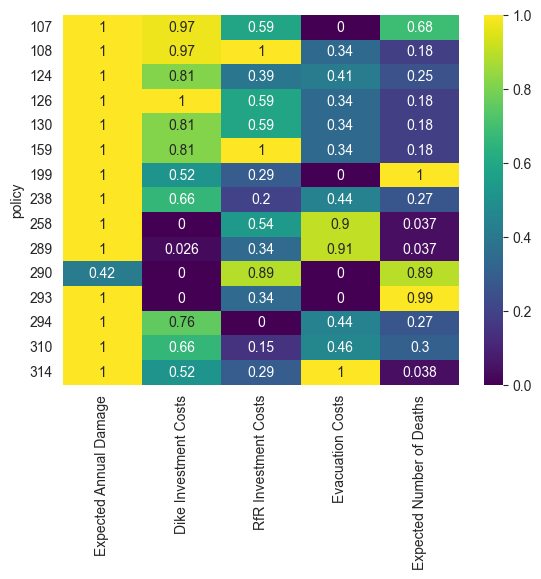

In [22]:
# Create a heat map of the maximum regret
# Standardize max regret on a scale from 0-1
max_regret = pd.DataFrame(max_regret)
sns.heatmap(max_regret/max_regret.max(), cmap='viridis', annot=True)

plt.yticks(rotation=0)

plt.savefig("Max_regret_heatmap200.png", dpi=300)
plt.show()

The heatmap shows the performance distribution of policies, showing that policies 258, 289 and 314 have the lowest maximum regret for the expected number of deaths. This means they consistently avoid poor outcomes in terms of fatalities across a wide range of scenarios. All of these three policies show a high maximum regret for the evacuation costs and the expected annual damage, indicating that in some scenarios, it performs significantly worse than the best alternative.
The maximum regret for the expected annual damage stands out, since it is very high for all except one policy. This could be caused by outliers, which is why the robustness will also be analysed by the 90th percentile regret below. Another interesting observation about these three policies is that for policy 258 and 289, the maximum regret for the dike investment costs is exceptionally low, while this is higher for policy 314.

Policy 258, 289 and 314 have the smallest maximum regret for the expected number of deaths, making them interesting candidate solutions. These three policies are a combination of the following active policy lever settings:

In [26]:
levers = [
    'A.1_DikeIncrease 0', 'A.1_DikeIncrease 1', 'A.1_DikeIncrease 2',
    'A.2_DikeIncrease 0', 'A.2_DikeIncrease 1', 'A.2_DikeIncrease 2',
    'A.3_DikeIncrease 0', 'A.3_DikeIncrease 1', 'A.3_DikeIncrease 2',
    'A.4_DikeIncrease 0', 'A.4_DikeIncrease 1', 'A.4_DikeIncrease 2',
    'A.5_DikeIncrease 0', 'A.5_DikeIncrease 1', 'A.5_DikeIncrease 2',
    '0_RfR 0', '0_RfR 1', '0_RfR 2',
    '1_RfR 0', '1_RfR 1', '1_RfR 2',
    '2_RfR 0', '2_RfR 1', '2_RfR 2',
    '3_RfR 0', '3_RfR 1', '3_RfR 2',
    '4_RfR 0', '4_RfR 1', '4_RfR 2',
    'EWS_DaysToThreat', 'policy'
]

# Create DataFrame with all levers
policy_df = experiments[levers]

# Select policies 258, 289, 314, keeping only one row and transposing for readability
robust_policies_duplicates = policy_df[policy_df['policy'].isin([258, 289, 314])]
robust_policies = robust_policies_duplicates.drop_duplicates(subset='policy', keep='first').set_index('policy').T

# Drop inactive levers
active_levers = robust_policies[(robust_policies != 0).any(axis=1)]

# Show the three policies
active_levers.head(11)

policy,258,289,314
A.3_DikeIncrease 0,0,0,1
A.4_DikeIncrease 0,1,2,1
0_RfR 0,0,0,1
0_RfR 1,1,1,0
2_RfR 0,0,1,0
2_RfR 1,1,0,0
2_RfR 2,1,1,1
3_RfR 0,1,0,1
3_RfR 1,1,1,0
3_RfR 2,1,1,1


In [17]:
robust_policies_duplicates = policy_df[policy_df['policy'].isin([ 314])]
robust_policies_duplicates

,A.1_DikeIncrease 0,A.1_DikeIncrease 1,A.1_DikeIncrease 2,A.2_DikeIncrease 0,A.2_DikeIncrease 1,A.2_DikeIncrease 2,A.3_DikeIncrease 0,A.3_DikeIncrease 1,A.3_DikeIncrease 2,A.4_DikeIncrease 0,...,2_RfR 1,2_RfR 2,3_RfR 0,3_RfR 1,3_RfR 2,4_RfR 0,4_RfR 1,4_RfR 2,EWS_DaysToThreat,policy
14000,0,0,0,0,0,0,1,0,0,1,...,0,1,1,0,1,0,0,0,3,314
14001,0,0,0,0,0,0,1,0,0,1,...,0,1,1,0,1,0,0,0,3,314
14002,0,0,0,0,0,0,1,0,0,1,...,0,1,1,0,1,0,0,0,3,314
14003,0,0,0,0,0,0,1,0,0,1,...,0,1,1,0,1,0,0,0,3,314
14004,0,0,0,0,0,0,1,0,0,1,...,0,1,1,0,1,0,0,0,3,314
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14995,0,0,0,0,0,0,1,0,0,1,...,0,1,1,0,1,0,0,0,3,314
14996,0,0,0,0,0,0,1,0,0,1,...,0,1,1,0,1,0,0,0,3,314
14997,0,0,0,0,0,0,1,0,0,1,...,0,1,1,0,1,0,0,0,3,314
14998,0,0,0,0,0,0,1,0,0,1,...,0,1,1,0,1,0,0,0,3,314


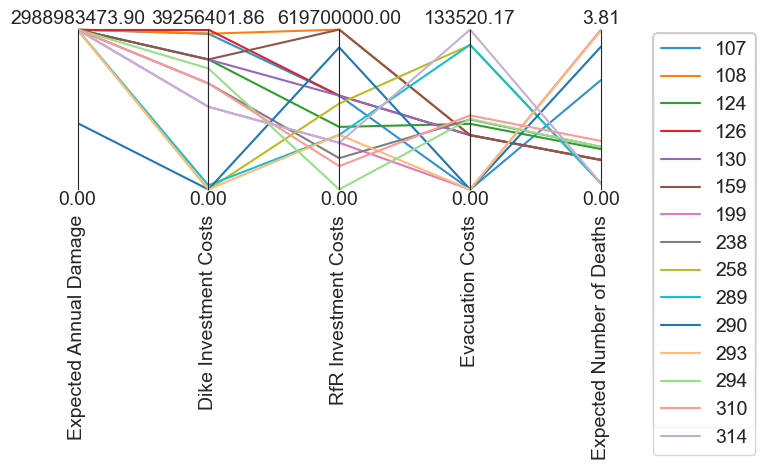

In [36]:
# Create parallel coordinate plot for maximum regret
colors = len(data.columns) * ["#3290d4", '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b', '#e377c2', '#7f7f7f', '#bcbd22', '#17becf', '#1f77b4', '#ffbb78', '#98df8a', '#ff9896', '#c5b0d5', '#c49c94', '#f7b6d2', '#c7c7c7', '#dbdb8d', '#9edae5']

data = max_regret

# makes it easier to identify the policy associated with each line
# in the parcoords plot

limits = parcoords.get_limits(data)
limits.loc[0, [
    'Expected Annual Damage',
    'Dike Investment Costs',
    'RfR Investment Costs',
    'Evacuation Costs',
    'Expected Number of Deaths'
]] = 0

paraxes = parcoords.ParallelAxes(limits)

for i, (index, row) in enumerate(data.iterrows()):
    paraxes.plot(row.to_frame().T, label=str(index), color=colors[i])
    paraxes.legend()

plt.savefig("Max_regret_parcoords200.png", dpi=300)
plt.show()

The parallel coordinate plot above shows the maximum regret for the different policies per outcome. These results are the same as the heatmap, but the parallel coordinate plot can make the trade-offs more apparent. The plot shows that there are no big regret trade-offs for expected annual damage and dike investment cost. However, almost all policies have a high regret for the expected damages and this results in a wide range of regrets for dike investments, making it difficult to draw clear conclusions. Furthermore, the lines between the other outcomes are crossing and thus show trade-offs. This indicates that it will be difficult to find a policy that is robust for all five outcomes.

#### 90th percentile max regret
Rather than only using the absolute maximum regret, the 90th percentile maximum regret is a bit less risk averse. This approach balances robustness with realism by reducing sensitivity to extreme outlier scenarios while still emphasizing performance under challenging conditions. As covered in McPhail et al. (2018), this percentile-based regret measure is more statistically stable and provides a more nuanced view of policy performance under deep uncertainty. It avoids overly conservative decisions that may result from focusing solely on worst-case scenarios.

In [37]:
experiments, outcomes = load_results("re_evaluation200.tar.gz")

# Convert array to DataFrame
outcomes_df = pd.DataFrame.from_records(outcomes)

# Define relevant columns
key_cols = ["scenario", "policy"]
outcome_names = ['Expected Annual Damage', 'Dike Investment Costs', 'RfR Investment Costs', 'Evacuation Costs', 'Expected Number of Deaths']

# Merge selected data and outcomes
df = pd.concat([experiments[key_cols], outcomes_df[outcome_names]], axis=1)

# 90th percentile dictionary to store regret results
regret_90p = {}

for outcome in outcome_names:
    # Scenario × Policy matrix
    matrix = df.pivot(index="scenario", columns="policy", values=outcome)

    # Regret matrix: difference for best outcome per scenario -> for each scenario, subtract the best policy outcome
    regret = matrix.subtract(matrix.min(axis=1), axis=0)

    # Compute the 90th percentile of regret per policy
    regret_90p[outcome] = regret.quantile(0.9)

# Combine results into one DataFrame
regret_90p_df = pd.DataFrame(regret_90p)

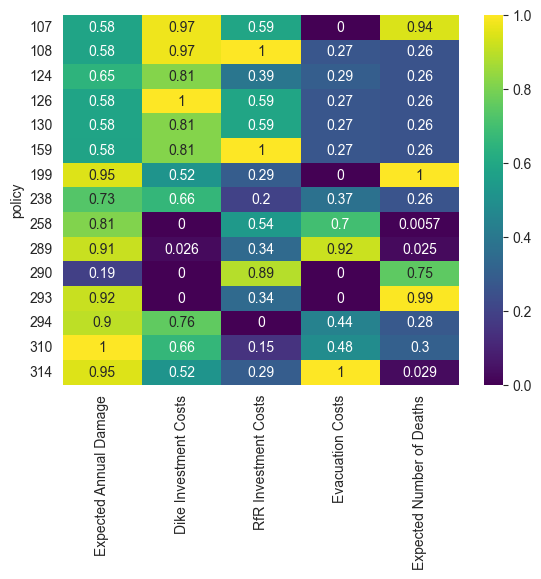

In [38]:
# Create a heat map of the 90th percentile max regret
# Standardize max regret on a scale from 0-1
max_regret = pd.DataFrame(max_regret)
sns.heatmap(regret_90p_df/regret_90p_df.max(), cmap='viridis', annot=True)

plt.yticks(rotation=0)

plt.savefig("Max_regret_heatmap200.png", dpi=300)
plt.show()

Comparing this heatmap with the one form the maximum regret helps to see how outliers play a role. From the heatmap of the 90th percentile max regret, it can immediately be observed that the earlier high regret values for the expected annual damage were caused by outliers, because the regret is significantly lower now for most policies. For the dike investment costs, the values are exactly the same, indicating that these values are not influenced by outliers. This is also the case for the RfR investment costs. For the evacuation costs, the values are generally lower, with the biggest difference being observed in one of the earlier mentioned policies, number 258. The maximum regret is also slightly lowered for the expected number of deaths.

## Step 4: Using scenario discovery to detect the vulnerabilities of the candidate solutions

A different but interesting question is which combination of uncertainties result in poor performance of the policies. To answer this, a scenario discovery using PRIM (Patient Rule Induction Method) is performed. The focus is on understanding which combination of uncertainties results in an expected number of deaths higher than 0.001. Since minimizing fatalities is a key policy objective, scenario discovery helps uncover the combinations of uncertain factors that lead to adverse outcomes.

The PRIM results are visualised and a point is chosen that tries to maximize density and coverage. The results attached to this point are then further analysed to see which uncertainties explain the poor performance of deaths.


In [51]:
experiments, outcomes = load_results('re_evaluation200.tar.gz')

# Remove levers from experiments DataFrame
cleaned_experiments = experiments.drop(labels=[
    'A.1_DikeIncrease 0', 'A.1_DikeIncrease 1', 'A.1_DikeIncrease 2',
    'A.2_DikeIncrease 0', 'A.2_DikeIncrease 1', 'A.2_DikeIncrease 2',
    'A.3_DikeIncrease 0', 'A.3_DikeIncrease 1', 'A.3_DikeIncrease 2',
    'A.4_DikeIncrease 0', 'A.4_DikeIncrease 1', 'A.4_DikeIncrease 2',
    'A.5_DikeIncrease 0', 'A.5_DikeIncrease 1', 'A.5_DikeIncrease 2',
    '0_RfR 0', '0_RfR 1', '0_RfR 2',
    '1_RfR 0', '1_RfR 1', '1_RfR 2',
    '2_RfR 0', '2_RfR 1', '2_RfR 2',
    '3_RfR 0', '3_RfR 1', '3_RfR 2',
    '4_RfR 0', '4_RfR 1', '4_RfR 2',
    'EWS_DaysToThreat', 'policy'
], axis=1)

In [52]:
# Perform PRIM analysis
# Want to check which uncertainties lead to the most deaths (poor performance)
y = outcomes['Expected Number of Deaths'] > 0.001

prim_alg = prim.Prim(cleaned_experiments, y, threshold=0.5, peel_alpha=0.05)
box = prim_alg.find_box()

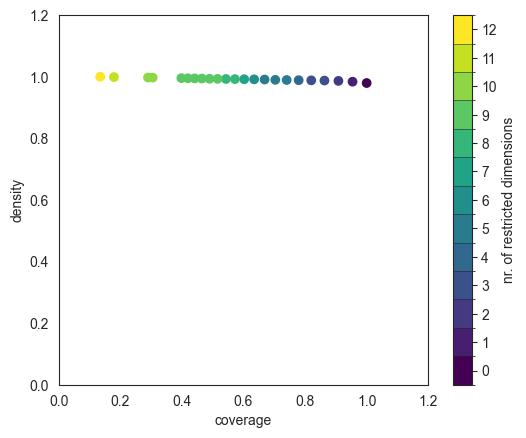

In [53]:
box.inspect_tradeoff()

# Visualize PRIM results
box.show_tradeoff()
plt.savefig('Prim_curve200.png')
plt.show()

The figure above shows the trade-offs between coverage, density and the number of restricted dimensions. In all cases, the density is exceptionally high, which means that nearly all the points inside the boxes meet the target condition, i.e., they are failures to the constraint of the expected number of deaths being lower than 0.001. Since density is high for all values, a box with a relatively high coverage (above 0.8) but also a low number of restricted dimensions was chosen: point number 4. Box 4 is further analyzed below.


coverage        0.820186
density         0.988192
id              4.000000
k           12051.000000
mass            0.813000
mean            0.988192
n           12195.000000
res_dim         3.000000
Name: 4, dtype: float64

                  box 4                             
                    min       max qp value  qp value
A.5_pfail  2.465347e-04  0.897807      NaN  0.000471
A.2_pfail  4.617010e-07  0.946788      NaN  0.003348
A.3_pfail  3.116547e-04  0.948557      NaN  0.159597



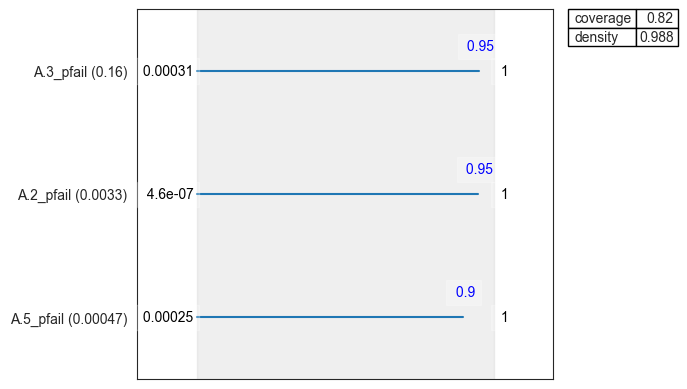

In [54]:
box.inspect(4)
box.inspect(4, style='graph')

plt.savefig('Prim_uncertainties200.png')
plt.show()

The results above show that the failing of the dikes in ring 2, 3 and 5 are most important for the poor outcomes, explaining most failure cases with very high confidence (99.8%). The three uncertainties are the drivers of the system’s failure. However, the qp-value for the failure of A3 is higher than 0.05 indicating that those results are not significant. The other two are significant, so by reducing the failure probabilities of A2 and A5 by targeted risk reduction, the systems safety could greatly improve.

Finally, to have a better understanding of this box 4 a scatter plot is created.

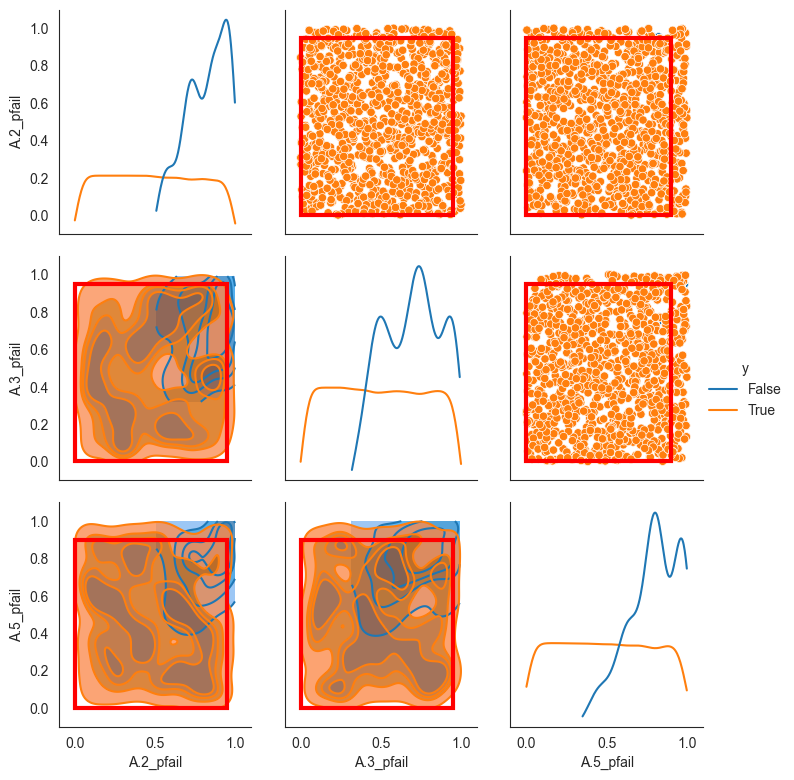

In [55]:
# Create plot showing box 4 on a scatter plot
box.select(4)
box.show_pairs_scatter()
fig = plt.gcf()
fig.set_size_inches(8,8)

plt.savefig('Prim_scatter_plot200.png')
plt.show()

The scatter plot shows that the box is relatively large, and it contains almost all points (True and False). Only a few blue points can be spotted, indicating that almost all policies (when re-evaluated for the 1000 scenarios) fail to meet the constraint of expected number of deaths < 0.001. Or, since poor performance is investigated here, they all meet the condition of the expected number of deaths > 0.001 (True). So, almost all policies show poor performance for this outcome. However, it is good to mention that the threshold of 0.001 indicates that a maximum of 0.2 people will die because of a flood in the next 200 years. This is a very risk averse constraint and the results above don't automatically mean that in all cases many casualties will occur. It could be interesting to investigate in further research how the scenario discovery results change when a less constraining threshold is chosen as a y-value.

To conclude, the scenario discovery results suggest that the breaking of the dikes at Cortenoever (A2) and Deventer (A5) would result in the highest amount of casualties, for the 15 candidate solutions. This is no surprise looking at the locations of these dikes, because Cortenoever is just upstream of Zutphen which is a big city with many inhabitants, same as Deventer. Breaking of the dikes at these locations would influence more people, thereby also potentially causing more casualties. Therefore, building and further deliberating on the policies, extra emphasis should be put on these two dikes.